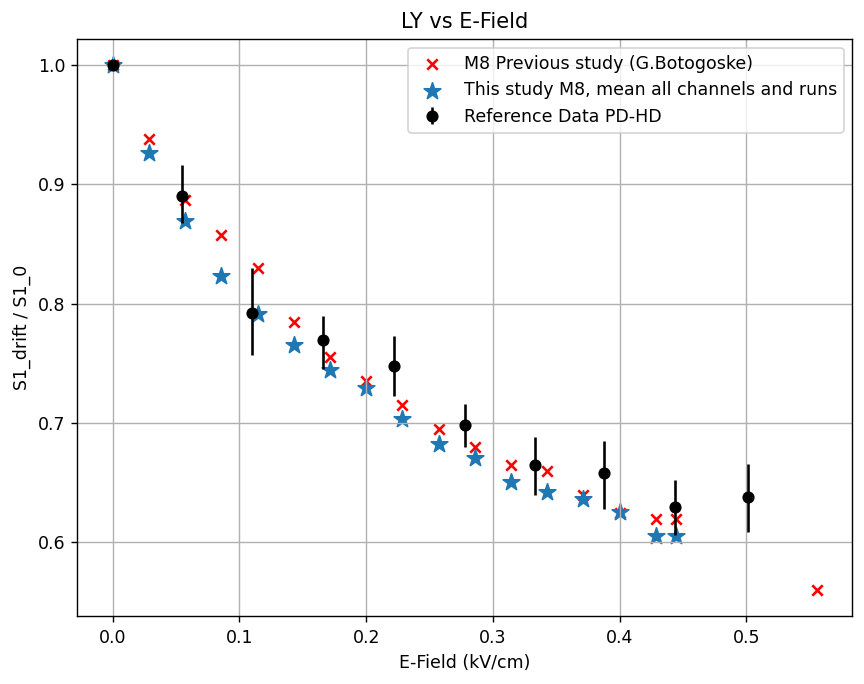

In [15]:
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import re
import time

path_templates = Path("../../filter/templates_large_pulses/")
templates_ch_2070_charge = np.trapz(np.loadtxt(path_templates / "template_43229_M7_1.txt"))
templates_ch_2071_charge = np.trapz(np.loadtxt(path_templates / "template_43229_M7_2.txt"))
templates_ch_2080_charge = np.trapz(np.loadtxt(path_templates / "template_42321_M8_1.txt"))
templates_ch_2081_charge = np.trapz(np.loadtxt(path_templates / "template_42321_M8_2.txt"))

list_templates_charge = {2070 : templates_ch_2070_charge, 
                         2071 : templates_ch_2071_charge, 
                         2080 : templates_ch_2080_charge, 
                         2081 : templates_ch_2081_charge }

path_waveforms = Path("../../coincidence/selected_waveforms/")
csv_files_0_adc = sorted(path_waveforms.glob("channel_*_run_*min_amplitude_0_adc.csv"))

run_to_efield = {
    # Zero-field reference
    39510: 0.0,

    # Increasing HV scan
    39511: 0.028571,
    39512: 0.057143,
    39514: 0.085714,
    39515: 0.114286,
    39516: 0.142857,
    39517: 0.171429,
    39518: 0.200000,
    39519: 0.228571,
    39521: 0.257143,
    39522: 0.285714,
    39523: 0.314286,
    39525: 0.342857,
    39526: 0.371429,
    39527: 0.400000,
    39528: 0.428571,
    39529: 0.444857,

    # Decreasing HV scan
    39500: 0.444857,
    39501: 0.400000,
    39502: 0.342857,
    39503: 0.285714,
    39504: 0.228571,
    39506: 0.171429,
    39507: 0.114286,
    39508: 0.057143,
}

E = [
    0.000,
    0.055,
    0.110,
    0.166,
    0.222,
    0.278,
    0.333,
    0.388,
    0.444,
    0.501,
]

S1 = [
    1.000,
    0.890,
    0.792,
    0.770,
    0.748,
    0.698,
    0.665,
    0.658,
    0.630,
    0.638,
]

S1_err_low = [
    0.000,
    0.022,
    0.035,
    0.025,
    0.025,
    0.018,
    0.025,
    0.030,
    0.024,
    0.029,
]

S1_err_high = [
    0.000,
    0.026,
    0.038,
    0.020,
    0.025,
    0.018,
    0.023,
    0.027,
    0.022,
    0.028,
]

def Calc_Charge(waveform, template_charge):
    return np.trapz(waveform[50:500]) / template_charge

s1_0_0_adc = {}
s1_0_1000_adc = {}

for csv_file in csv_files_0_adc:
    match = re.search(r"channel_(\d+)_run_(\d+)", csv_file.name)

    if not match:
        continue

    channel = int(match.group(1))
    run = match.group(2)

    if run == "039510":
        mean_waveform = pd.read_csv(csv_file)["mean"].to_numpy()

        charge = Calc_Charge(
            mean_waveform,
            list_templates_charge[channel],
        )

        s1_0_0_adc[channel] = charge



plt.figure(dpi=125, figsize=(8, 6))

channel_points_0_adc = defaultdict(lambda: {"efield": [], "relative_s1": []})



for csv_file in csv_files_0_adc:

    match = re.search(r"channel_(\d+)_run_(\d+)", csv_file.name)

    if not match:
        continue

    channel = int(match.group(1))
    run = match.group(2)

    if channel not in list_templates_charge:
        print(f"Channel {channel} not found in templates. Skipping.")
        continue
    if int(run) not in run_to_efield:
        print(f"Run {run} not found in run_to_efield. Skipping.")
        continue

    if channel not in s1_0_0_adc:
        print(f"No run 039510 reference found for channel {channel}. Skipping.")
        continue

    mean_waveform = pd.read_csv(csv_file)["mean"].to_numpy()

    channel_points_0_adc[channel]["efield"].append(run_to_efield[int(run)])
    channel_points_0_adc[channel]["relative_s1"].append(
        Calc_Charge(mean_waveform, list_templates_charge[channel]) / s1_0_0_adc[channel]
    )


points_by_efield = {}

for channel in sorted(channel_points_0_adc):
    if channel in (2070, 2071):
        continue

    for efield, relative_s1 in zip(
        channel_points_0_adc[channel]["efield"],
        channel_points_0_adc[channel]["relative_s1"],
    ):
        points_by_efield.setdefault(efield, []).append(relative_s1)

efields = sorted(points_by_efield)
means = [np.mean(points_by_efield[efield]) for efield in efields]

# Approximate ProtoDUNE-VD M8 points digitized from the figure
relative_s1_previous = np.array([
    1.000, 0.938, 0.887, 0.858, 0.830, 0.785,
    0.755, 0.735, 0.715, 0.695, 0.680, 0.665,
    0.660, 0.640, 0.625, 0.620, 0.620, 0.560,
])

efield_previous = np.append(np.asarray(efields, dtype=float), 0.556)

plt.scatter(
    efield_previous,
    relative_s1_previous,
    marker="x",
    color="red",
    label="M8 Previous study (G.Botogoske)",
)

plt.scatter(efields, means, label="This study M8, mean all channels and runs", marker="*", s=100)

plt.errorbar(E, S1, yerr=[S1_err_low, S1_err_high], color="black", label="Reference Data PD-HD", zorder=10, fmt='o')
plt.grid()
plt.legend()
plt.xlabel("E-Field (kV/cm)")
plt.ylabel("S1_drift / S1_0")
plt.title("LY vs E-Field")
plt.show()


